# 🎯 DoNext 5G — NB4_DSO1 : Prédiction Handover Binaire

**Pipeline :** NB1 ✅ → NB2 ✅ → NB3 ✅ → **NB4_DSO1**

---
### 🎯 Objectif
Prédire si un handover va se produire (classification binaire).
Utilise `cluster_id` (zone NB2 ST-DBSCAN) comme feature clé.

| # | Modèle | Type |
|---|--------|------|
| M1 | XGBoost | Gradient Boosting |
| M2 | LightGBM | Gradient Boosting |
| M3 | Random Forest | Ensemble |
| M4 | BiLSTM | Deep Learning (fenêtre T-5) |
| M5 | TabNet | Deep Learning tabulaire |



---
## Section 0 — Setup & Chargement


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import json, os, gc, pickle, warnings
import pyarrow.parquet as pq
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Bidirectional, Dense, Dropout,
    BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer
import torch

plt.rcParams.update({
    'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D27',
    'axes.edgecolor':'#3A3D4D','axes.labelcolor':'#E0E0E0',
    'axes.titlecolor':'#FFFFFF','xtick.color':'#B0B0B0',
    'ytick.color':'#B0B0B0','text.color':'#E0E0E0',
    'grid.color':'#2A2D3A','grid.linestyle':'--',
    'grid.alpha':0.5,'font.family':'monospace','figure.dpi':130
})

BLUE='#4FC3F7'; GREEN='#69F0AE'; ORANGE='#FFB74D'
RED='#EF5350'; PURPLE='#CE93D8'
CM_LABELS = ['No HO', 'HO']

DATASET_ROOT  = r'C:\Users\THINKPAD\Desktop\DATASET'
PT_OUT_DIR    = os.path.join(DATASET_ROOT, 'PT_output')
FE_OUT_DIR    = os.path.join(DATASET_ROOT, 'FE_output')
MODEL_OUT_DIR = os.path.join(DATASET_ROOT, 'MODEL_output', 'DSO1')
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

print('✅ Setup OK')

✅ Setup OK


In [2]:
# ── Chargement données NB3 ──────────────────────────────────
idx_train = np.load(os.path.join(PT_OUT_DIR,'idx_train.npy'), allow_pickle=True)
idx_val   = np.load(os.path.join(PT_OUT_DIR,'idx_val.npy'),   allow_pickle=True)
idx_test  = np.load(os.path.join(PT_OUT_DIR,'idx_test.npy'),  allow_pickle=True)
y_train   = np.load(os.path.join(PT_OUT_DIR,'y_train.npy'))
y_val     = np.load(os.path.join(PT_OUT_DIR,'y_val.npy'))
y_test    = np.load(os.path.join(PT_OUT_DIR,'y_test.npy'))

with open(os.path.join(PT_OUT_DIR,'config.json')) as f:
    config = json.load(f)
COLS_X = config['cols_X']

#  Vérifier cluster_id présent
print('Vérifications config NB3:')
print(f'  cluster_id dans COLS_X : {"cluster_id" in COLS_X}')
print(f'  has_no_leakage         : {config.get("has_no_leakage", "?")} ')
print(f'  Total features         : {len(COLS_X)}')
print(f'  idx cluster_id         : {COLS_X.index("cluster_id") if "cluster_id" in COLS_X else "ABSENT"}')

assert 'cluster_id' in COLS_X, \
    '❌ cluster_id absent! Relancer NB3 corrigé.'

# Chargement parquet (colonnes features seulement)
print('\nChargement df_preprocessed.parquet...')
df = pd.read_parquet(
    os.path.join(PT_OUT_DIR, 'df_preprocessed.parquet'),
    columns=COLS_X
)
gc.collect()

# Extraction float32
X_train = df.loc[idx_train].values.astype(np.float32); gc.collect()
X_val   = df.loc[idx_val].values.astype(np.float32);   gc.collect()
X_test  = df.loc[idx_test].values.astype(np.float32)
del df; gc.collect()

ratio = int((1-y_train.mean()) / max(y_train.mean(), 1e-6))
print(f'\n✅ X_train {X_train.shape}')
print(f'   HO%={y_train.mean()*100:.2f}% | ratio 1:{ratio}')
print(f'   X_val  {X_val.shape}')
print(f'   X_test {X_test.shape}')

Vérifications config NB3:
  cluster_id dans COLS_X : True
  has_no_leakage         : True 
  Total features         : 101
  idx cluster_id         : 100

Chargement df_preprocessed.parquet...

✅ X_train (8822003, 101)
   HO%=4.08% | ratio 1:23
   X_val  (1890428, 101)
   X_test (1890432, 101)


---
## Section 1 — M1 : XGBoost


In [3]:
print('='*60+'\n  M1 — XGBoost\n'+'='*60)

# ✅ cluster_id est dans X_train (NB3 corrigé)
# XGBoost gère nativement les entiers négatifs
# (-2=static, -1=outlier, 0-204=cluster)

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    early_stopping_rounds=30,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f'✅ best_iteration={xgb_model.best_iteration}')

  M1 — XGBoost
[0]	validation_0-aucpr:0.93129
[50]	validation_0-aucpr:0.95621
[100]	validation_0-aucpr:0.96093
[150]	validation_0-aucpr:0.96445
[200]	validation_0-aucpr:0.96606
[250]	validation_0-aucpr:0.96670
[300]	validation_0-aucpr:0.96707
[350]	validation_0-aucpr:0.96695
[354]	validation_0-aucpr:0.96700
✅ best_iteration=324


In [4]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_xgb, target_names=CM_LABELS))

metrics_xgb = {
    'model':     'XGBoost',
    'f1':        round(f1_score(y_test, y_pred_xgb), 4),
    'precision': round(precision_score(y_test, y_pred_xgb), 4),
    'recall':    round(recall_score(y_test, y_pred_xgb), 4),
    'auc_roc':   round(roc_auc_score(y_test, y_prob_xgb), 4),
    'auc_pr':    round(average_precision_score(y_test, y_prob_xgb), 4)
}
print(f"\n  XGBoost → F1={metrics_xgb['f1']} AUC-PR={metrics_xgb['auc_pr']}")

with open(os.path.join(MODEL_OUT_DIR,'xgb_model.pkl'),'wb') as f:
    pickle.dump(xgb_model, f)
print('✅ xgb_model.pkl sauvegardé')

              precision    recall  f1-score   support

       No HO       0.92      0.90      0.91   1458781
          HO       0.68      0.74      0.71    431651

    accuracy                           0.86   1890432
   macro avg       0.80      0.82      0.81   1890432
weighted avg       0.87      0.86      0.86   1890432


  XGBoost → F1=0.7097 AUC-PR=0.8831
✅ xgb_model.pkl sauvegardé


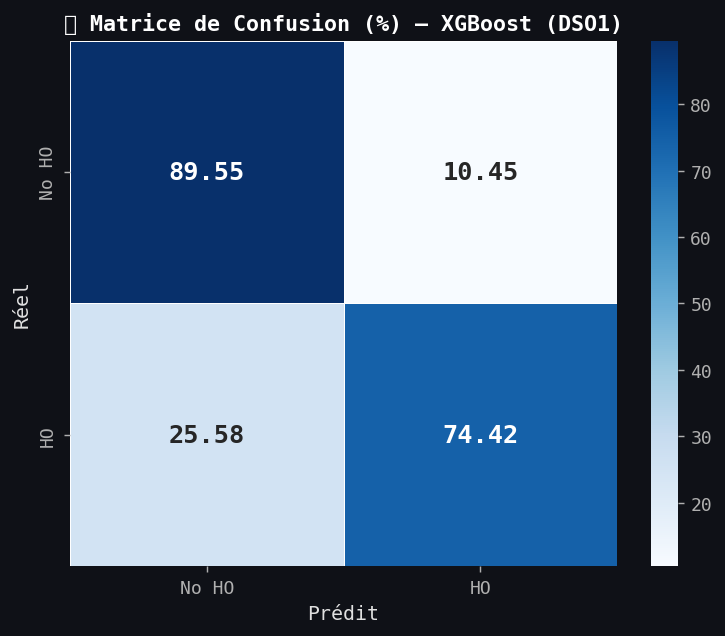

VN: 89.55% | FP: 10.45%
FN: 25.58% | VP: 74.42%


In [5]:
# ── Matrice de Confusion — XGBoost ───────────────────────────
cm_xgb  = confusion_matrix(y_test, y_pred_xgb)
cm_pct  = cm_xgb.astype('float') / cm_xgb.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_pct*100, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CM_LABELS, yticklabels=CM_LABELS,
    linewidths=0.5, ax=ax, annot_kws={'size':14,'weight':'bold'})
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.set_title('📊 Matrice de Confusion (%) — XGBoost (DSO1)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_xgb_dso1_pct.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f"VN: {cm_pct[0,0]*100:.2f}% | FP: {cm_pct[0,1]*100:.2f}%")
print(f"FN: {cm_pct[1,0]*100:.2f}% | VP: {cm_pct[1,1]*100:.2f}%")

---
## Section 2 — M2 : LightGBM


In [6]:
print('='*60+'\n  M2 — LightGBM\n'+'='*60)

# ✅ cluster_id dans X_train
# LightGBM supporte nativement les features catégorielles
# cluster_id traité comme entier (0-204)

lgbm_model = LGBMClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    metric='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(30, verbose=False),
        lgb.log_evaluation(50)
    ]
)
print('✅ LightGBM entraîné')

  M2 — LightGBM
[50]	valid_0's average_precision: 0.961546
[100]	valid_0's average_precision: 0.96514
[150]	valid_0's average_precision: 0.967221
[200]	valid_0's average_precision: 0.968902
[250]	valid_0's average_precision: 0.969785
[300]	valid_0's average_precision: 0.970079
✅ LightGBM entraîné


In [7]:
y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_lgbm, target_names=CM_LABELS))

metrics_lgbm = {
    'model':     'LightGBM',
    'f1':        round(f1_score(y_test, y_pred_lgbm), 4),
    'precision': round(precision_score(y_test, y_pred_lgbm), 4),
    'recall':    round(recall_score(y_test, y_pred_lgbm), 4),
    'auc_roc':   round(roc_auc_score(y_test, y_prob_lgbm), 4),
    'auc_pr':    round(average_precision_score(y_test, y_prob_lgbm), 4)
}
print(f"\n  LightGBM → F1={metrics_lgbm['f1']} AUC-PR={metrics_lgbm['auc_pr']}")

with open(os.path.join(MODEL_OUT_DIR,'lgbm_model.pkl'),'wb') as f:
    pickle.dump(lgbm_model, f)
print('✅ lgbm_model.pkl sauvegardé')

              precision    recall  f1-score   support

       No HO       0.92      0.90      0.91   1458781
          HO       0.70      0.75      0.72    431651

    accuracy                           0.87   1890432
   macro avg       0.81      0.82      0.82   1890432
weighted avg       0.87      0.87      0.87   1890432


  LightGBM → F1=0.7197 AUC-PR=0.8672
✅ lgbm_model.pkl sauvegardé


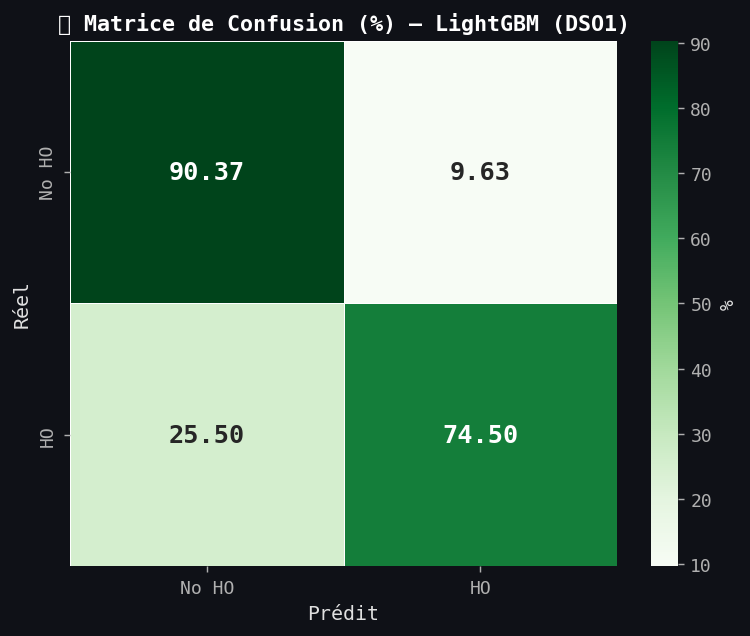

VN: 90.37% | FP: 9.63%
FN: 25.50% | VP: 74.50%


In [8]:
# ── Matrice de Confusion — LightGBM ─────────────────────────
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
cm_pct  = cm_lgbm.astype('float') / cm_lgbm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_pct*100, annot=True, fmt='.2f', cmap='Greens',
    xticklabels=CM_LABELS, yticklabels=CM_LABELS,
    linewidths=0.5, ax=ax,
    annot_kws={'size':14,'weight':'bold'},
    cbar_kws={'label': '%'})
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.set_title('📊 Matrice de Confusion (%) — LightGBM (DSO1)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_lgbm_dso1_pct.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f"VN: {cm_pct[0,0]*100:.2f}% | FP: {cm_pct[0,1]*100:.2f}%")
print(f"FN: {cm_pct[1,0]*100:.2f}% | VP: {cm_pct[1,1]*100:.2f}%")

---
## Section 3 — M3 : Random Forest


In [9]:
print('='*60+'\n  M3 — Random Forest\n'+'='*60)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced_subsample',
    max_samples=0.2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_model.fit(X_train, y_train)
print('✅ Random Forest entraîné')

  M3 — Random Forest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  7.2min


✅ Random Forest entraîné


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 12.2min finished


In [10]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_rf, target_names=CM_LABELS))

metrics_rf = {
    'model':     'Random Forest',
    'f1':        round(f1_score(y_test, y_pred_rf), 4),
    'precision': round(precision_score(y_test, y_pred_rf), 4),
    'recall':    round(recall_score(y_test, y_pred_rf), 4),
    'auc_roc':   round(roc_auc_score(y_test, y_prob_rf), 4),
    'auc_pr':    round(average_precision_score(y_test, y_prob_rf), 4)
}
print(f"\n  RF → F1={metrics_rf['f1']} AUC-PR={metrics_rf['auc_pr']}")

with open(os.path.join(MODEL_OUT_DIR,'rf_model.pkl'),'wb') as f:
    pickle.dump(rf_model, f)
print('✅ rf_model.pkl sauvegardé')

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    5.5s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    9.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    5.5s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    9.7s finished


              precision    recall  f1-score   support

       No HO       0.92      0.93      0.93   1458781
          HO       0.75      0.74      0.74    431651

    accuracy                           0.88   1890432
   macro avg       0.84      0.83      0.84   1890432
weighted avg       0.88      0.88      0.88   1890432


  RF → F1=0.745 AUC-PR=0.8815
✅ rf_model.pkl sauvegardé


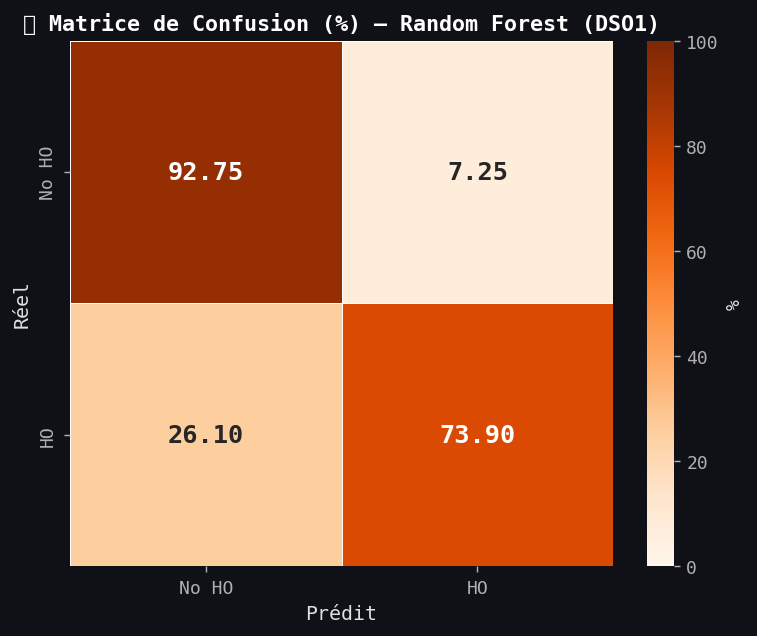

VN: 92.75% | FP: 7.25%
FN: 26.10% | VP: 73.90%


In [11]:
# ── Matrice de Confusion — Random Forest ─────────────────────
cm_rf  = confusion_matrix(y_test, y_pred_rf)
cm_pct = cm_rf.astype('float') / cm_rf.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_pct*100, annot=True, fmt='.2f', cmap='Oranges',
    xticklabels=CM_LABELS, yticklabels=CM_LABELS,
    linewidths=0.5, ax=ax,
    annot_kws={'size':14,'weight':'bold'},
    cbar_kws={'label': '%'}, vmin=0, vmax=100)
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.set_title('📊 Matrice de Confusion (%) — Random Forest (DSO1)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_rf_dso1_pct.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f"VN: {cm_pct[0,0]*100:.2f}% | FP: {cm_pct[0,1]*100:.2f}%")
print(f"FN: {cm_pct[1,0]*100:.2f}% | VP: {cm_pct[1,1]*100:.2f}%")

---
## Section 4 — M4 : BiLSTM


In [12]:
print('='*60+'\n  M4 — BiLSTM\n'+'='*60)

# ✅ CORRECTION BUG: '_t-{k}' → '_T{k}'
# NB2 génère: rsrp_T1, rsrp_T2... (majuscule, sans tiret)
WINDOW_COLS = [
    c for c in COLS_X
    if any(f'_T{k}' in c for k in range(1, 6))
]

print(f'  WINDOW_COLS trouvées : {len(WINDOW_COLS)}')
print(f'  Exemples : {WINDOW_COLS[:5]}')

# cluster_id est dans COLS_X mais PAS dans WINDOW_COLS
# BiLSTM utilise seulement les features temporelles T1..T5
# cluster_id utilisé par XGBoost/LightGBM (statique par mesure)
print(f'  cluster_id dans WINDOW_COLS: {"cluster_id" in WINDOW_COLS}')
print(f'  → Normal: cluster_id est statique, pas temporel')

T = 5 if WINDOW_COLS else 1

if WINDOW_COLS:
    w_idx = [list(COLS_X).index(c) for c in WINDOW_COLS]
    F     = len(w_idx) // T
    print(f'  T={T}, F={F}')
    print(f'  Shape 3D: (n, {T}, {F})')
    X_tr_3d = X_train[:, w_idx].reshape(-1, T, F)
    X_va_3d = X_val[:,   w_idx].reshape(-1, T, F)
    X_te_3d = X_test[:,  w_idx].reshape(-1, T, F)
else:
    print('  ⚠️ WINDOW_COLS vide → fallback (T=1)')
    F = X_train.shape[1]
    T = 1
    X_tr_3d = X_train.reshape(-1, 1, F)
    X_va_3d = X_val.reshape(-1,   1, F)
    X_te_3d = X_test.reshape(-1,  1, F)

print(f'  X_tr_3d : {X_tr_3d.shape}')
print(f'  X_va_3d : {X_va_3d.shape}')
print(f'  X_te_3d : {X_te_3d.shape}')

# ── Architecture BiLSTM ───────────────────────────────────────
tf.random.set_seed(42)

inp = Input(shape=(T, F))
x   = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(inp)
x   = BatchNormalization()(x)
x   = Bidirectional(LSTM(64, return_sequences=False, dropout=0.2))(x)
x   = BatchNormalization()(x)
x   = Dense(64, activation='relu')(x)
x   = Dropout(0.3)(x)
out = Dense(1, activation='sigmoid')(x)

lstm_model = Model(inputs=inp, outputs=out, name='BiLSTM_DSO1')
lstm_model.compile(
    optimizer=Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['AUC']
)

# Sample weights pour déséquilibre 1:ratio
sw = np.where(y_train == 1, ratio, 1).astype(np.float32)

print(f'\n  Entraînement BiLSTM...')
history = lstm_model.fit(
    X_tr_3d, y_train,
    validation_data=(X_va_3d, y_val),
    sample_weight=sw,
    epochs=30,
    batch_size=2048,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor='val_AUC', patience=5,
            restore_best_weights=True, mode='max'
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6
        ),
        ModelCheckpoint(
            os.path.join(MODEL_OUT_DIR, 'lstm_best.h5'),
            monitor='val_AUC', save_best_only=True, mode='max'
        ),
    ]
)
print('✅ BiLSTM entraîné')

  M4 — BiLSTM
  WINDOW_COLS trouvées : 45
  Exemples : ['rsrp_T1', 'rsrp_T2', 'rsrp_T3', 'rsrp_T4', 'rsrp_T5']
  cluster_id dans WINDOW_COLS: False
  → Normal: cluster_id est statique, pas temporel
  T=5, F=9
  Shape 3D: (n, 5, 9)
  X_tr_3d : (8822003, 5, 9)
  X_va_3d : (1890428, 5, 9)
  X_te_3d : (1890432, 5, 9)

  Entraînement BiLSTM...
Epoch 1/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - AUC: 0.8812 - loss: 0.7464      

4308/4308 ━━━━━━━━━━━━━━━━━━━━ 11693s 3s/step - AUC: 0.9450 - loss: 0.5510 - val_AUC: 0.8382 - val_loss: 0.3162 - learning_rate: 0.0010
Epoch 2/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 12626s 3s/step - AUC: 0.9691 - loss: 0.4161 - val_AUC: 0.3310 - val_loss: 0.7174 - learning_rate: 0.0010
Epoch 3/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 3863s 897ms/step - AUC: 0.9718 - loss: 0.3975 - val_AUC: 0.5649 - val_loss: 0.5795 - learning_rate: 0.0010
Epoch 4/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 1443s 335ms/step - AUC: 0.9735 - loss: 0.3859 - val_AUC: 0.3688 - val_loss: 0.6889 - learning_rate: 0.0010
Epoch 5/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 1404s 326ms/step - AUC: 0.9752 - loss: 0.3729 - val_AUC: 0.3649 - val_loss: 0.6276 - learning_rate: 5.0000e-04
Epoch 6/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 2638s 612ms/step - AUC: 0.9759 - loss: 0.3677 - val_AUC: 0.7315 - val_loss: 0.4934 - learning_rate: 5.0000e-04
✅ BiLSTM entraîné


In [13]:
y_prob_lstm = lstm_model.predict(
    X_te_3d, batch_size=4096, verbose=0
).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)
print(classification_report(y_test, y_pred_lstm, target_names=CM_LABELS))

metrics_lstm = {
    'model':     'BiLSTM',
    'f1':        round(f1_score(y_test, y_pred_lstm), 4),
    'precision': round(precision_score(y_test, y_pred_lstm), 4),
    'recall':    round(recall_score(y_test, y_pred_lstm), 4),
    'auc_roc':   round(roc_auc_score(y_test, y_prob_lstm), 4),
    'auc_pr':    round(average_precision_score(y_test, y_prob_lstm), 4)
}
print(f"\n  BiLSTM → F1={metrics_lstm['f1']} AUC-PR={metrics_lstm['auc_pr']}")

lstm_model.save(os.path.join(MODEL_OUT_DIR,'lstm_model.h5'))
print('✅ lstm_model.h5 sauvegardé')

              precision    recall  f1-score   support

       No HO       0.76      0.86      0.81   1458781
          HO       0.12      0.06      0.08    431651

    accuracy                           0.68   1890432
   macro avg       0.44      0.46      0.44   1890432
weighted avg       0.61      0.68      0.64   1890432




  BiLSTM → F1=0.0804 AUC-PR=0.5422
✅ lstm_model.h5 sauvegardé


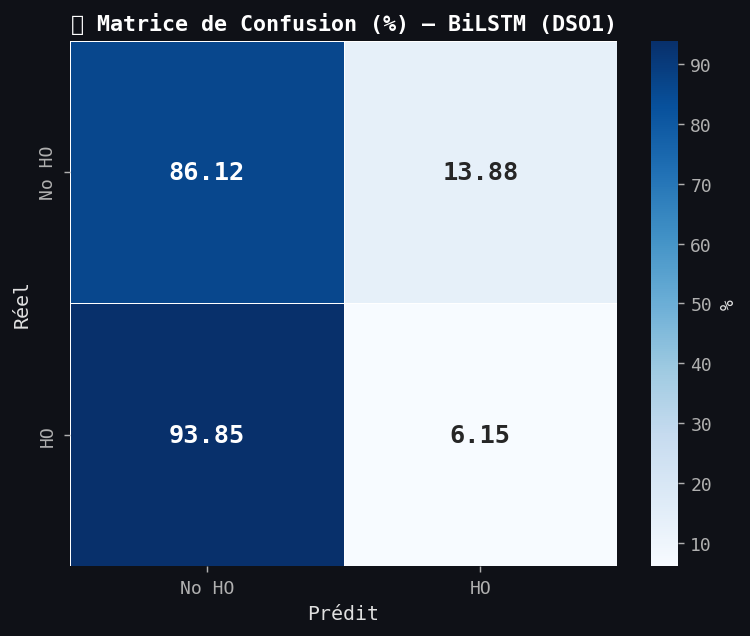

VN: 86.12% | FP: 13.88%
FN: 93.85% | VP: 6.15%


In [14]:
# ── Matrice de Confusion — BiLSTM ────────────────────────────
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
cm_pct  = cm_lstm.astype('float') / cm_lstm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_pct*100, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CM_LABELS, yticklabels=CM_LABELS,
    linewidths=0.5, ax=ax,
    annot_kws={'size':14,'weight':'bold'},
    cbar_kws={'label': '%'})
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.set_title('📊 Matrice de Confusion (%) — BiLSTM (DSO1)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_lstm_dso1_pct.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f"VN: {cm_pct[0,0]*100:.2f}% | FP: {cm_pct[0,1]*100:.2f}%")
print(f"FN: {cm_pct[1,0]*100:.2f}% | VP: {cm_pct[1,1]*100:.2f}%")

---
## Section 5 — M5 : TabNet


In [15]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'show',
                       'pytorch-tabnet', '-q'])

0

In [16]:
print('='*60+'\n  M5 — TabNet\n'+'='*60)

# ── 1. Sampling ───────────────────────────────────────────────
N_TN = 300_000
idx_sample = np.random.choice(len(X_train), N_TN, replace=False)
X_tr_tn    = X_train[idx_sample]
X_va_tn    = X_val.copy()
X_te_tn    = X_test.copy()
y_train_tn = y_train[idx_sample]
print(f'Sample train : {len(X_tr_tn):,}')

# ✅ CORRECTION: TabNetPretrainer défini AVANT son utilisation
# Pré-entraînement non supervisé sur les features
print('\nPré-entraînement non supervisé (TabNetPretrainer)...')
pretrainer = TabNetPretrainer(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    mask_type='entmax',
    verbose=5, seed=42
)
pretrainer.fit(
    X_train=X_tr_tn,
    eval_set=[X_va_tn],
    max_epochs=20,
    patience=5,
    batch_size=4096,
    virtual_batch_size=512,
    pretraining_ratio=0.8
)
print('✅ Pré-entraînement terminé')

# ── 2. Modèle supervisé ───────────────────────────────────────
tabnet_model = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2,
    mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=0, seed=42
)

# Mini-fit pour initialiser le réseau
tabnet_model.fit(
    X_train=X_tr_tn[:512],
    y_train=y_train_tn[:512].astype(int),
    max_epochs=1, batch_size=512,
    virtual_batch_size=512
)

# Transfert des poids du pretrainer
tabnet_model.load_weights_from_unsupervised(pretrainer)
print('✅ Poids pretrainer transférés')

# ── 3. Entraînement supervisé réel ───────────────────────────
tabnet_model.verbose = 10
tabnet_model.fit(
    X_train=X_tr_tn,
    y_train=y_train_tn.astype(int),
    eval_set=[(X_va_tn, y_val.astype(int))],
    eval_metric=['auc'],
    max_epochs=30, patience=5,
    batch_size=4096, virtual_batch_size=512,
    weights=1
)
print('✅ TabNet entraîné')

  M5 — TabNet
Sample train : 300,000

Pré-entraînement non supervisé (TabNetPretrainer)...
epoch 0  | loss: 1220.2341| val_0_unsup_loss_numpy: 23244.19140625|  0:23:10s
epoch 5  | loss: 1.33303 | val_0_unsup_loss_numpy: 71.06950378417969|  1:02:11s
epoch 10 | loss: 1.08689 | val_0_unsup_loss_numpy: 21.217069625854492|  1:26:04s
epoch 15 | loss: 0.99428 | val_0_unsup_loss_numpy: 11.308030128479004|  1:38:21s
Stop training because you reached max_epochs = 20 with best_epoch = 18 and best_val_0_unsup_loss_numpy = 6.783659934997559
✅ Pré-entraînement terminé
✅ Poids pretrainer transférés
epoch 0  | loss: 0.50698 | val_0_auc: 0.90706 |  0:01:13s
epoch 10 | loss: 0.16849 | val_0_auc: 0.97921 |  0:15:37s

Early stopping occurred at epoch 15 with best_epoch = 10 and best_val_0_auc = 0.97921
✅ TabNet entraîné


In [18]:
y_pred_tn = tabnet_model.predict(X_te_tn)
y_prob_tn = tabnet_model.predict_proba(X_te_tn)[:,1]
print(classification_report(y_test, y_pred_tn, target_names=CM_LABELS))

metrics_tn = {
    'model':     'TabNet',
    'f1':        round(f1_score(y_test, y_pred_tn), 4),
    'precision': round(precision_score(y_test, y_pred_tn), 4),
    'recall':    round(recall_score(y_test, y_pred_tn), 4),
    'auc_roc':   round(roc_auc_score(y_test, y_prob_tn), 4),
    'auc_pr':    round(average_precision_score(y_test, y_prob_tn), 4)
}
print(f"\n  TabNet → F1={metrics_tn['f1']} AUC-PR={metrics_tn['auc_pr']}")

tabnet_model.save_model(os.path.join(MODEL_OUT_DIR,'tabnet_model'))
print('✅ tabnet_model sauvegardé')

              precision    recall  f1-score   support

       No HO       0.99      0.88      0.93   1458781
          HO       0.71      0.97      0.82    431651

    accuracy                           0.90   1890432
   macro avg       0.85      0.93      0.88   1890432
weighted avg       0.93      0.90      0.91   1890432


  TabNet → F1=0.8216 AUC-PR=0.9233
Successfully saved model at C:\Users\THINKPAD\Desktop\DATASET\MODEL_output\DSO1\tabnet_model.zip
✅ tabnet_model sauvegardé


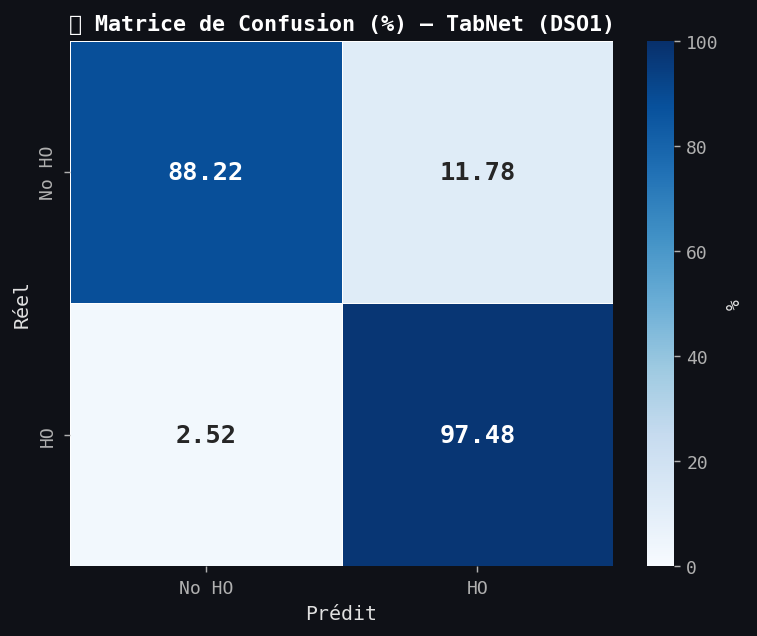

VN: 88.22% | FP: 11.78%
FN: 2.52% | VP: 97.48%


In [19]:
# ── Matrice de Confusion — TabNet ────────────────────────────
cm_tn  = confusion_matrix(y_test, y_pred_tn)
cm_pct = cm_tn.astype('float') / cm_tn.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_pct*100, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CM_LABELS, yticklabels=CM_LABELS,
    linewidths=0.5, ax=ax,
    annot_kws={'size':14,'weight':'bold'},
    cbar_kws={'label': '%'}, vmin=0, vmax=100)
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.set_title('📊 Matrice de Confusion (%) — TabNet (DSO1)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_tabnet_dso1_pct.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f"VN: {cm_pct[0,0]*100:.2f}% | FP: {cm_pct[0,1]*100:.2f}%")
print(f"FN: {cm_pct[1,0]*100:.2f}% | VP: {cm_pct[1,1]*100:.2f}%")

---
## Section 6 — Analyse SHAP (importance cluster_id)


In [20]:
# ── SHAP — Importance features  ──────────────────────
# 
# Référence: Lundberg & Lee (2017) — SHAP values

try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,'-m','pip','install','shap','-q'])
    import shap

print('Calcul SHAP ')

# Échantillon pour SHAP (RAM)
N_SHAP  = 5000
idx_sh  = np.random.choice(len(X_test), N_SHAP, replace=False)
X_shap  = X_test[idx_sh]

explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_shap)

# shap_values peut être une liste [class0, class1]
if isinstance(shap_values, list):
    sv = shap_values[1]  # class HO=1
else:
    sv = shap_values

# Importance moyenne absolue par feature
mean_shap = np.abs(sv).mean(axis=0)
shap_df   = pd.DataFrame({
    'feature': COLS_X,
    'shap':    mean_shap
}).sort_values('shap', ascending=False)

print('\nTop 20 features SHAP:')
print(shap_df.head(20).to_string(index=False))

# Vérifier rang de cluster_id
if 'cluster_id' in shap_df['feature'].values:
    rang = shap_df['feature'].tolist().index('cluster_id') + 1
    val  = shap_df[shap_df['feature']=='cluster_id']['shap'].values[0]
    print(f'\n  ✅ cluster_id: rang #{rang} — SHAP={val:.4f}')
else:
    print('  ❌ cluster_id non trouvé dans SHAP')

# Sauvegarder SHAP
shap_df.to_json(
    os.path.join(MODEL_OUT_DIR,'shap_lgbm_dso1.json'),
    orient='records', indent=2
)
print('✅ shap_lgbm_dso1.json sauvegardé')

Calcul SHAP sur LightGBM (meilleur modèle)...

Top 20 features SHAP:
         feature     shap
     network_enc 0.683473
     tx_power_T1 0.651328
           nr_ri 0.537183
      device_enc 0.478141
           is_5g 0.450732
         rsrp_T1 0.367459
    mean_latency 0.286646
            rsrp 0.280621
            rssi 0.267654
         has_gps 0.234241
          cqi_T1 0.233838
         sinr_T1 0.220527
            sinr 0.179995
     max_latency 0.179780
             cqi 0.170382
    tx_power_gap 0.144875
            rsrq 0.134107
packet_loss_mean 0.134071
         ss_sinr 0.132987
         rssi_T1 0.131160

  ✅ cluster_id: rang #52 — SHAP=0.0266
✅ shap_lgbm_dso1.json sauvegardé


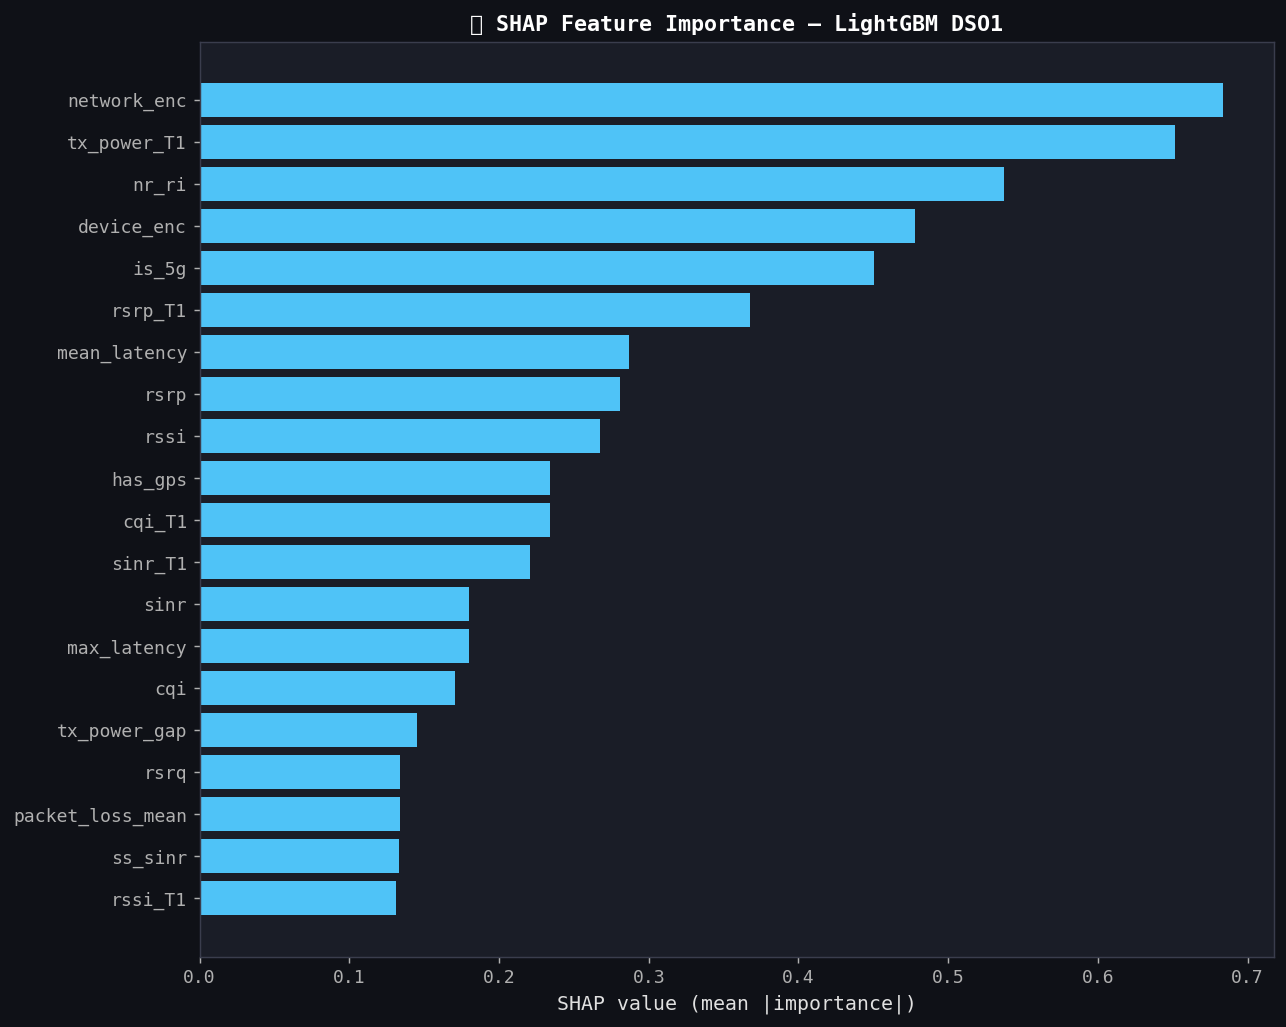

In [21]:
# ── SHAP Plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

top20      = shap_df.head(20)
colors_bar = [
    RED if f == 'cluster_id' else BLUE
    for f in top20['feature']
]

ax.barh(top20['feature'][::-1], top20['shap'][::-1],
        color=colors_bar[::-1])
ax.set_xlabel('SHAP value (mean |importance|)', fontsize=11)
ax.set_title('🔍 SHAP Feature Importance — LightGBM DSO1',
             fontsize=12, fontweight='bold')

# Annotation cluster_id
if 'cluster_id' in top20['feature'].values:
    ax.annotate(
        '← cluster_id (zone NB2)',
        xy=(top20[top20['feature']=='cluster_id']['shap'].values[0],
            top20['feature'].tolist()[::-1].index('cluster_id')),
        fontsize=9, color=RED
    )

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'shap_dso1.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

---
## Section 7 — Grille comparative


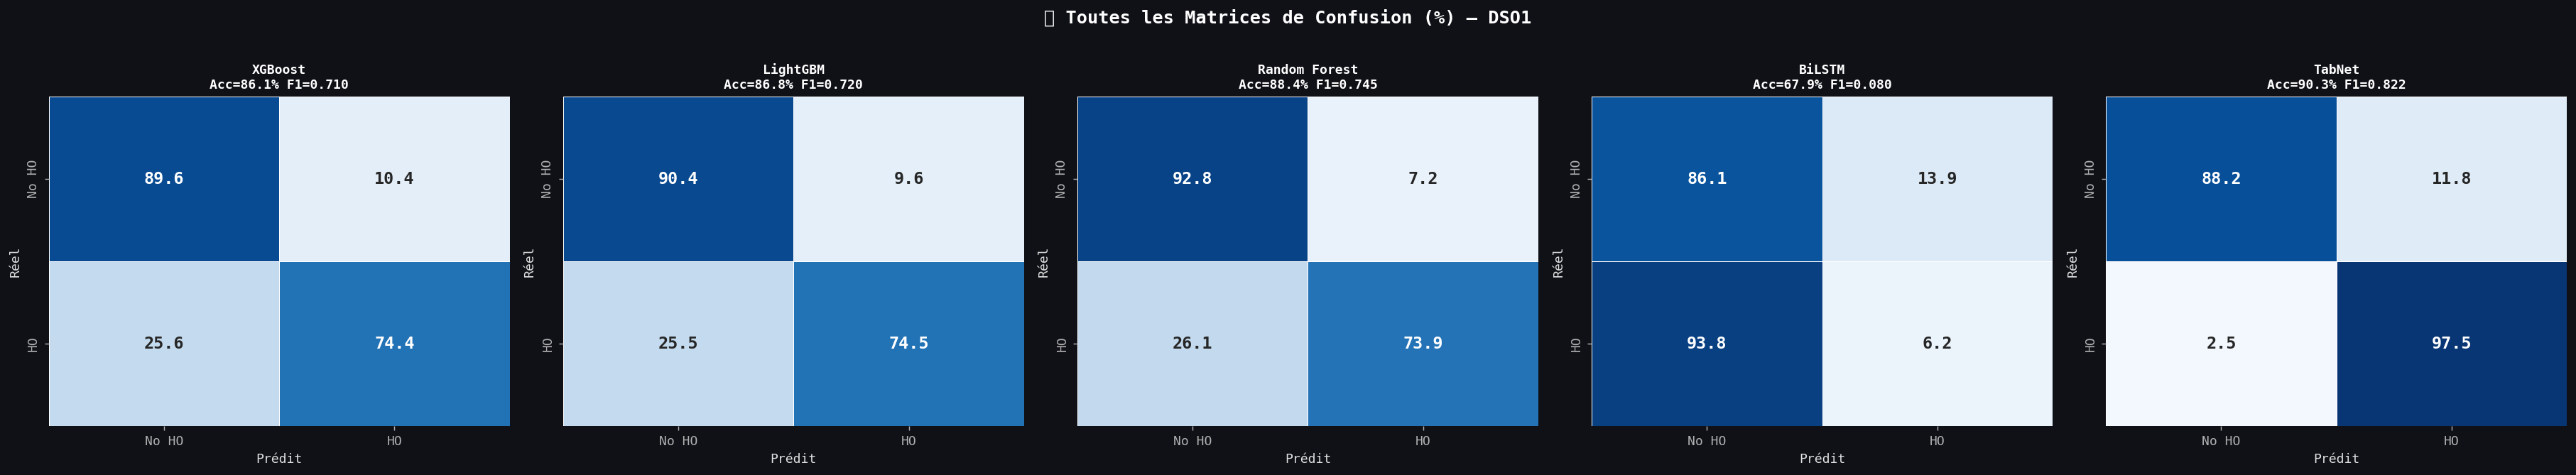

In [24]:
# ── Grille comparative — TOUTES EN POURCENTAGE ───────────────
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

models_cm = [
    ('XGBoost',       cm_xgb,  y_pred_xgb),
    ('LightGBM',      cm_lgbm, y_pred_lgbm),
    ('Random Forest', cm_rf,   y_pred_rf),
    ('BiLSTM',        cm_lstm, y_pred_lstm),
    ('TabNet',        cm_tn,   y_pred_tn),
]

for ax, (name, cm, y_pred) in zip(axes, models_cm):
    # ✅ Normalisation en % par ligne
    cm_pct = cm.astype('float') / (
        cm.sum(axis=1, keepdims=True) + 1e-9
    ) * 100

    f1  = f1_score(y_test, y_pred, zero_division=0)
    acc = (np.diag(cm).sum() / cm.sum()) * 100

    sns.heatmap(
        cm_pct,
        annot=True,
        fmt='.1f',
        cmap='Blues',           # ✅ toutes en bleu
        xticklabels=CM_LABELS,
        yticklabels=CM_LABELS,
        linewidths=0.5,
        ax=ax,
        annot_kws={'size': 13, 'weight': 'bold'},
        cbar=False,
        vmin=0,
        vmax=100
    )
    ax.set_title(
        f'{name}\nAcc={acc:.1f}% F1={f1:.3f}',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle(
    '📊 Toutes les Matrices de Confusion (%) — DSO1',
    fontsize=14, fontweight='bold', color='white', y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR, 'cm_all_dso1.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()

---
## Section 8 — Comparaison finale



=== RÉSULTATS DSO1 ===
                   f1  precision  recall  auc_roc  auc_pr
model                                                    
XGBoost        0.7097     0.6782  0.7442   0.9432  0.8831
LightGBM       0.7197     0.6961  0.7450   0.9261  0.8672
Random Forest  0.7450     0.7511  0.7390   0.9420  0.8815
BiLSTM         0.0804     0.1160  0.0615   0.7894  0.5422
TabNet         0.8216     0.7100  0.9748   0.9717  0.9233

🏆 Meilleur (F1) : TabNet → 0.8216


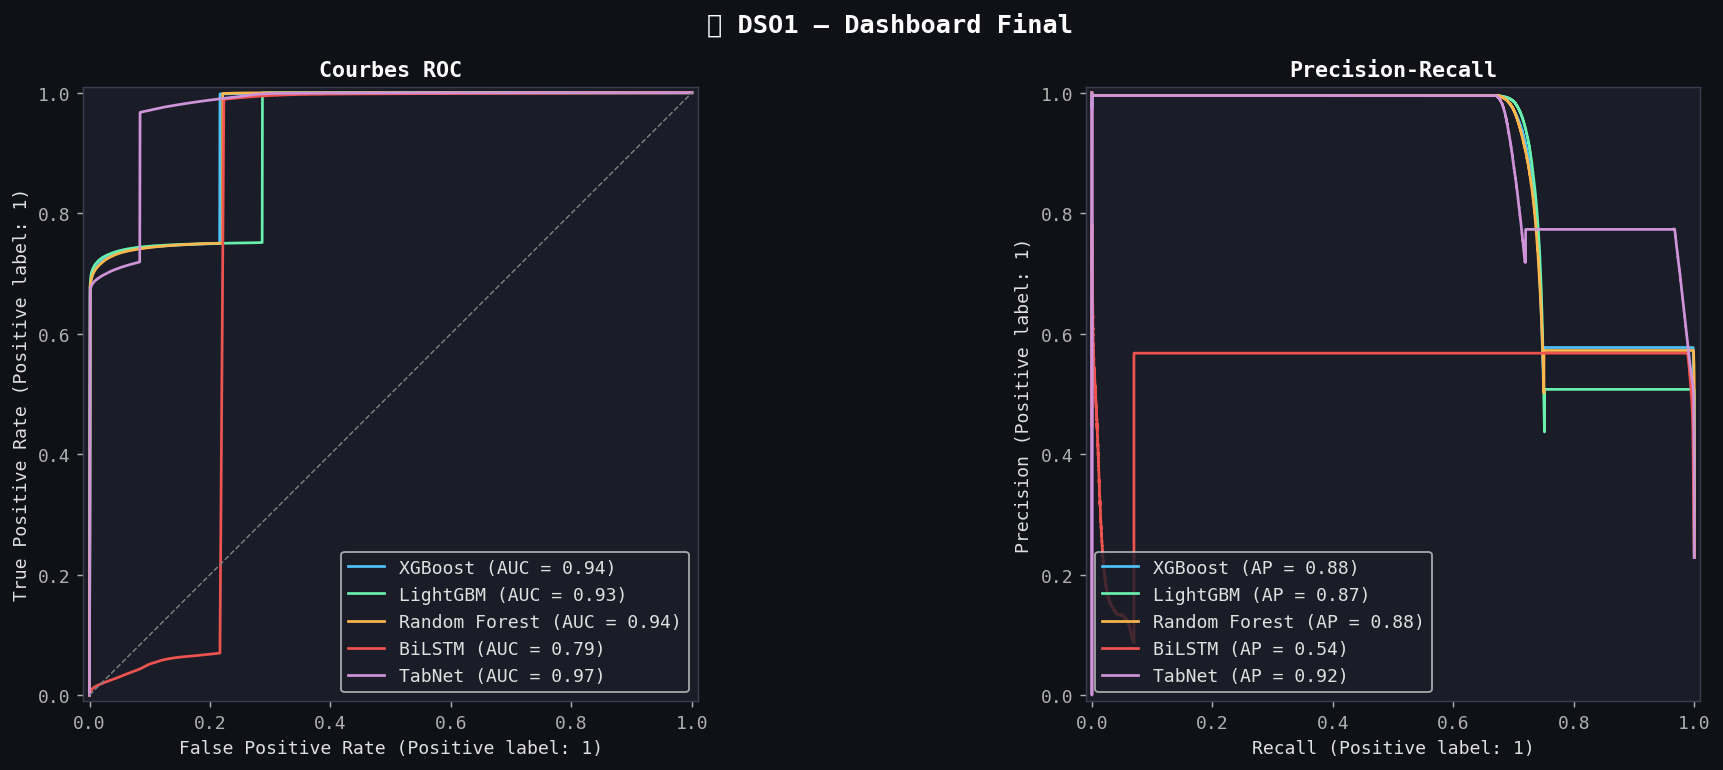


✅ results_dso1.json sauvegardé
   best_model    : TabNet
   best_f1       : 0.8216
   has_cluster_id: True
   cluster_id rank: #52


In [23]:
all_metrics = [metrics_xgb, metrics_lgbm, metrics_rf,
               metrics_lstm, metrics_tn]
df_results  = pd.DataFrame(all_metrics).set_index('model')

print('\n=== RÉSULTATS DSO1 ===')
print(df_results.to_string())

best = df_results['f1'].idxmax()
print(f'\n🏆 Meilleur (F1) : {best} → {df_results.loc[best,"f1"]:.4f}')

# Courbes ROC + PR
models_list = ['XGBoost','LightGBM','Random Forest','BiLSTM','TabNet']
probs_list  = [y_prob_xgb, y_prob_lgbm, y_prob_rf, y_prob_lstm, y_prob_tn]
colors_list = [BLUE, GREEN, ORANGE, RED, PURPLE]

fig, axes = plt.subplots(1, 2, figsize=(16,6))
for name, prob, color in zip(models_list, probs_list, colors_list):
    RocCurveDisplay.from_predictions(
        y_test, prob, name=name, ax=axes[0], color=color
    )
axes[0].set_title('Courbes ROC', fontweight='bold')
axes[0].plot([0,1],[0,1],'--',color='gray',lw=0.8)

for name, prob, color in zip(models_list, probs_list, colors_list):
    PrecisionRecallDisplay.from_predictions(
        y_test, prob, name=name, ax=axes[1], color=color
    )
axes[1].set_title('Precision-Recall', fontweight='bold')

plt.suptitle('🏆 DSO1 — Dashboard Final',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'dashboard_dso1.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

# ✅ Sauvegarde enrichie avec info cluster
results_enriched = {
    'models':          all_metrics,
    'best_model':      best,
    'best_f1':         float(df_results.loc[best,'f1']),
    'best_auc_pr':     float(df_results.loc[best,'auc_pr']),
    'n_features':      len(COLS_X),
    'has_cluster_id':  'cluster_id' in COLS_X,
    'cluster_id_rank': shap_df['feature'].tolist().index('cluster_id') + 1
                       if 'cluster_id' in shap_df['feature'].values else -1,
    'n_train':         int(len(idx_train)),
    'n_test':          int(len(idx_test)),
    'ho_rate_test':    float(y_test.mean()),
}

with open(os.path.join(MODEL_OUT_DIR,'results_dso1.json'),'w') as f:
    json.dump(results_enriched, f, indent=2)

print('\n✅ results_dso1.json sauvegardé')
print(f'   best_model    : {best}')
print(f'   best_f1       : {results_enriched["best_f1"]}')
print(f'   has_cluster_id: {results_enriched["has_cluster_id"]}')
print(f'   cluster_id rank: #{results_enriched["cluster_id_rank"]}')

---

### 📚 Références
- Chen & Guestrin (2016) — XGBoost
- Ke et al. (2017) — LightGBM
- Arik & Pfister (2021) — TabNet
- Lundberg & Lee (2017) — SHAP values
